In [19]:
import cv2
import matplotlib.pylab as plt
import numpy as np

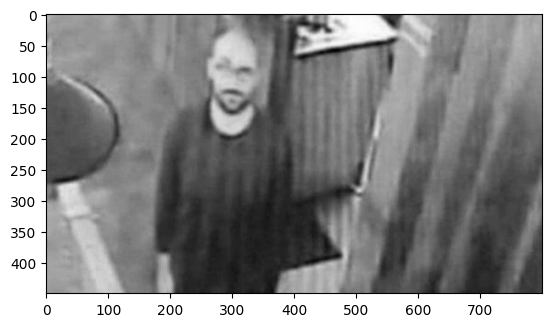

(450, 800)


In [ ]:
cctv = plt.imread('Assets/backup.jpg')
sisitv = cv2.cvtColor (cctv, cv2.COLOR_BGR2GRAY)
plt.imshow(sisitv, cmap = 'gray')
plt.show()
print(sisitv.shape)

In [28]:
def filter(img, size, mode):
    # dimensi gambar / image dimensions
    height, width = img.shape

    # ukuran padding / padding size
    pad = size // 2

    # tambah padding tepi / add edge padding
    padded = np.pad(img, pad, mode='edge')

    # kanvas hasil / output canvas
    canvas = np.zeros_like(img, dtype=np.uint8)

    match mode:

        case 'mean':
            # filter rata-rata / mean filter
            area = size * size

            for i in range(height):
                for j in range(width):

                    # area kernel / kernel region
                    region = padded[i:i+size, j:j+size].astype(np.float32)

                    # rumus mean manual / manual mean formula
                    total = 0
                    for row in region:
                        for val in row:
                            total += val

                    mean_val = total // area

                    # simpan hasil / save result
                    canvas[i, j] = mean_val

        case 'median':
            # filter median / median filter
            for i in range(height):
                for j in range(width):

                    # area kernel / kernel region
                    region = padded[i:i+size, j:j+size]

                    # rumus median manual / manual median formula
                    values = region.ravel().tolist()
                    values.sort()

                    mid = len(values) // 2
                    median_val = values[mid]

                    # simpan hasil / save result
                    canvas[i, j] = median_val

        case 'modus':
            # filter modus / mode filter
            for i in range(height):
                for j in range(width):

                    # area kernel / kernel region
                    region = padded[i:i+size, j:j+size]

                    # ratakan array / flatten array
                    values = region.ravel()

                    # hitung kemunculan / count occurrences
                    count = {}

                    for val in values:
                        if val in count:
                            count[val] += 1
                        else:
                            count[val] = 1

                    # cari nilai terbanyak / find mode value
                    max_count = 0
                    mode_val = 0

                    for val, freq in count.items():
                        if freq > max_count:
                            max_count = freq
                            mode_val = val

                    # simpan hasil / save result
                    canvas[i, j] = mode_val

    # kembalikan gambar / return image
    return canvas


# cara panggil / how to call
# hasil = filter(foto_karim, 3, 'mean')

In [29]:
def convolution(img, kernel):

    # ukuran kernel / kernel size
    size = kernel.shape[0]

    # ukuran padding / padding size
    pad_size = size // 2

    # tambah padding nol / add zero padding
    padded = np.pad(img, pad_size, mode='constant')

    # kanvas hasil / output canvas
    canvas = np.zeros_like(img).astype(np.float32)

    # dimensi gambar / image dimensions
    height, width = img.shape

    # loop baris / loop rows
    for i in range(height):

        # loop kolom / loop columns
        for j in range(width):

            # area kernel / kernel region
            region = padded[i:i+size, j:j+size]

            # hitung konvolusi / compute convolution
            canvas[i, j] = np.sum(region * kernel)

    # kembalikan gambar / return image
    return canvas


# cara panggil / how to call
# hasil = convolution(fotoMarsha, kernel)

In [30]:
# kernel penghalus gambar / image smoothing kernel
kernelSmoothing = np.array([
    [1/10, 1/10, 1/10],
    [1/10,  1/5, 1/10],
    [1/10, 1/10, 1/10]
])

# kernel penajam gambar / image sharpening kernel
kernelSharpening = np.array([
    [1/9, 1/9, 1/9],
    [1/9, 8/9, 1/9],
    [1/9, 1/9, 1/9]
])

In [31]:
# mean filter 3x3
mean3x3 = filter(sisitv, 3, 'mean')

# mean filter 9x9
mean9x9 = filter(sisitv, 9, 'mean')

# median filter 3x3
median3x3 = filter(sisitv, 3, 'median')

# median filter 9x9
median9x9 = filter(sisitv, 9, 'median')

# modus filter 3x3
modus3x3 = filter(sisitv, 3, 'modus')

# modus filter 9x9
modus9x9 = filter(sisitv, 9, 'modus')

# smoothing
smoothing = convolution(sisitv, kernelSmoothing)

# sharpening
sharpening = convolution(sisitv, kernelSharpening)

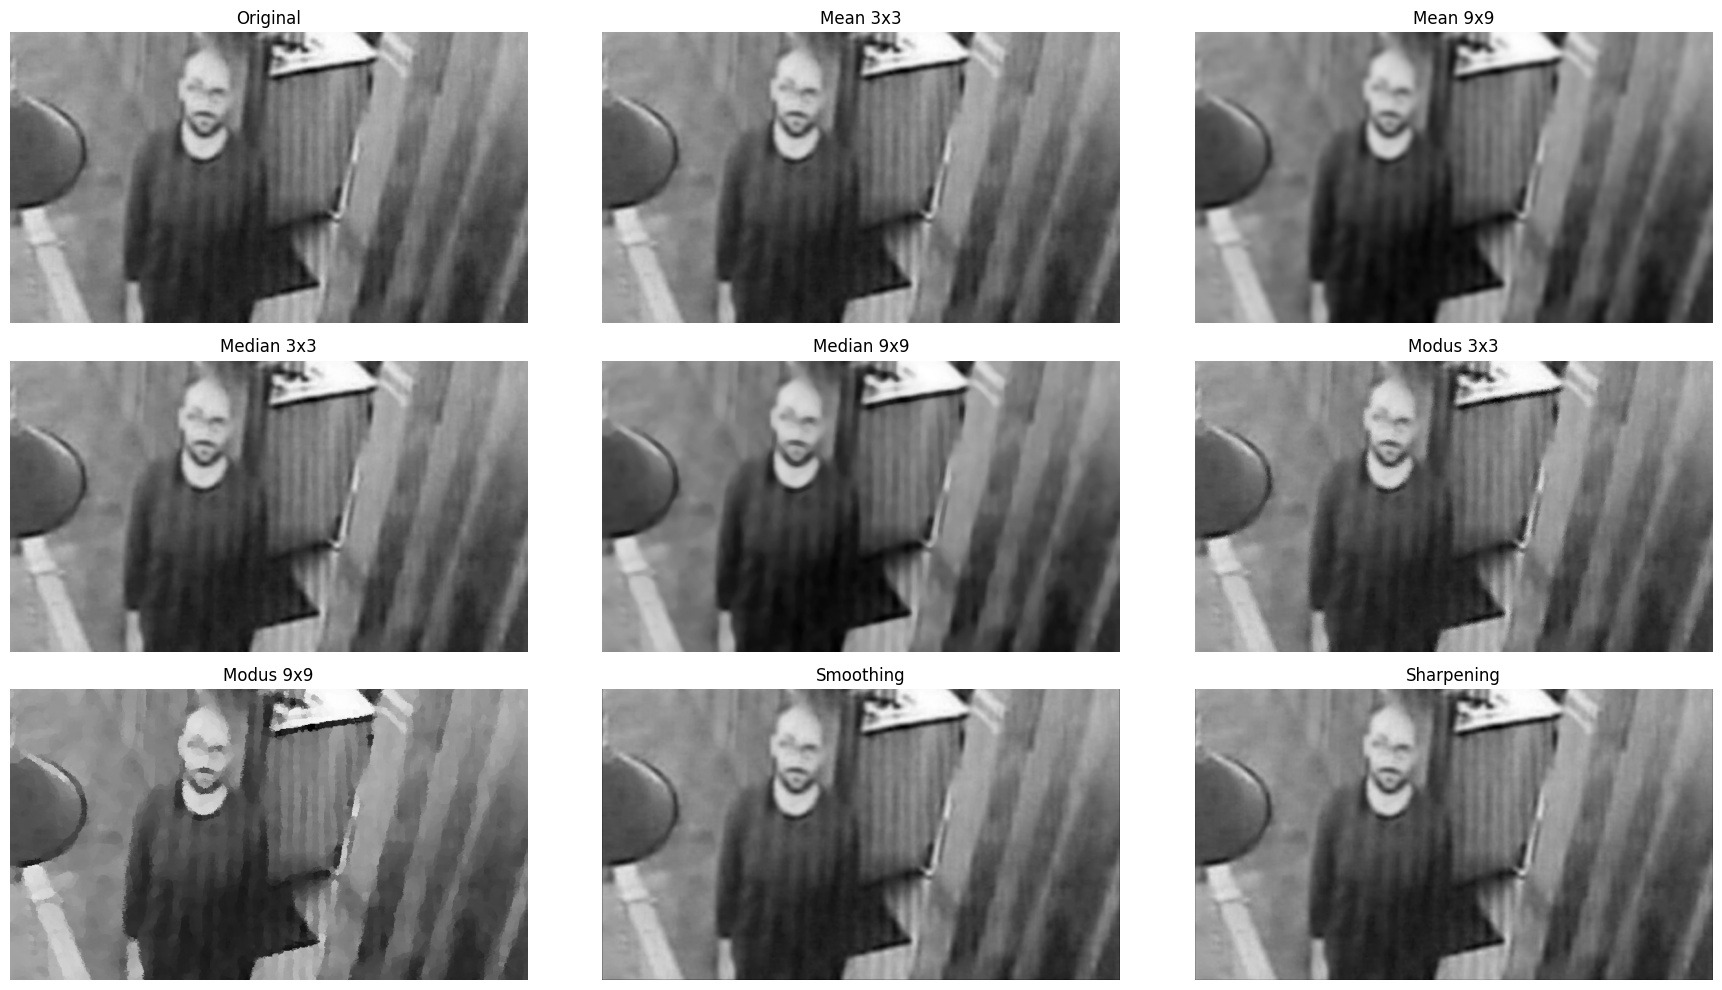

In [32]:
# tampilkan hasil
plt.figure(figsize=(18,10))

plt.subplot(3,3,1)
plt.imshow(sisitv, cmap='gray')
plt.title('Original')
plt.axis('off')

plt.subplot(3,3,2)
plt.imshow(mean3x3, cmap='gray')
plt.title('Mean 3x3')
plt.axis('off')

plt.subplot(3,3,3)
plt.imshow(mean9x9, cmap='gray')
plt.title('Mean 9x9')
plt.axis('off')

plt.subplot(3,3,4)
plt.imshow(median3x3, cmap='gray')
plt.title('Median 3x3')
plt.axis('off')

plt.subplot(3,3,5)
plt.imshow(median9x9, cmap='gray')
plt.title('Median 9x9')
plt.axis('off')

plt.subplot(3,3,6)
plt.imshow(modus3x3, cmap='gray')
plt.title('Modus 3x3')
plt.axis('off')

plt.subplot(3,3,7)
plt.imshow(modus9x9, cmap='gray')
plt.title('Modus 9x9')
plt.axis('off')

plt.subplot(3,3,8)
plt.imshow(smoothing, cmap='gray')
plt.title('Smoothing')
plt.axis('off')

plt.subplot(3,3,9)
plt.imshow(sharpening, cmap='gray')
plt.title('Sharpening')
plt.axis('off')

plt.tight_layout()
plt.show()

perbedaan dari mean, median, modus itu lebih terlihat di ukuran 9x9, hasil citra backup nya terlihat lebih gelap di beberapa bagian yang lebih gelap, sedangkan di ukuran 3x3 terlihat sedikit gelap walaupun hampir tidak terlihat hasil dari perbedaannya

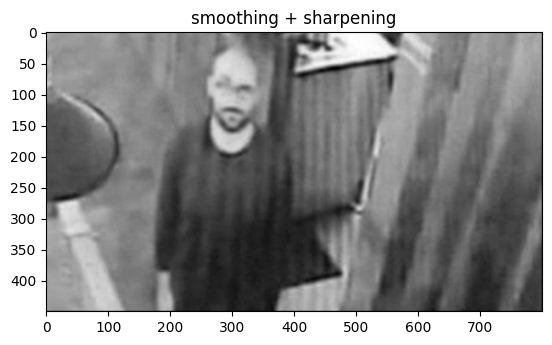

In [38]:
hasil = smoothing + sharpening

# tampilkan hasil
plt.imshow(hasil, cmap = 'gray')
plt.title("smoothing + sharpening")
plt.show()

fungsi dari smoothing digunakan untuk memperhalus citra backup yg sudah dijadikan grayscale menggunakan kernel dan citra backup lalu di konvolusikan. sharpening untuk menajamkan citra backup yg sudah dijadikan grayscale menggunakan kernel dan citra backup lalu di konvolusikan. penggabungan dari smoothing dan sharpening digunakan untuk membuat hasil citra backup lebih tajam dan halus

In [39]:
# kernel sobel sumbu x / x-axis sobel kernel
sobelX = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1]
], dtype=np.float32)

# kernel sobel sumbu y / y-axis sobel kernel
sobelY = np.array([
    [ 1,  2,  1],
    [ 0,  0,  0],
    [-1, -2, -1]
], dtype=np.float32)


# kernel prewitt sumbu x / x-axis prewitt kernel
prewittX = np.array([
    [-1, 0, 1],
    [-1, 0, 1],
    [-1, 0, 1]
], dtype=np.float32)

# kernel prewitt sumbu y / y-axis prewitt kernel
prewittY = np.array([
    [ 1,  1,  1],
    [ 0,  0,  0],
    [-1, -1, -1]
], dtype=np.float32)


# kernel roberts sumbu x / x-axis roberts kernel
robertsX = np.array([
    [ 1,  0],
    [ 0, -1]
], dtype=np.float32)

# kernel roberts sumbu y / y-axis roberts kernel
robertsY = np.array([
    [ 0,  1],
    [-1,  0]
], dtype=np.float32)

In [40]:
def edge(img, kernelx, kernely):

    # konvolusi sumbu x / x-axis convolution
    gx = convolution(img, kernelx)

    # konvolusi sumbu y / y-axis convolution
    gy = convolution(img, kernely)

    # kanvas kosong / empty canvas
    canvas = np.zeros_like(img, dtype=np.float32)

    # gabung gradient absolut / combine absolute gradients
    canvas = np.abs(gx) + np.abs(gy)

    # normalisasi ke 0-255 / normalize to 0-255
    canvas = canvas * 255.0 / np.max(canvas)

    # batas nilai dan konversi / clip values and convert
    return np.clip(canvas, 0, 255).astype(np.uint8)


# cara panggil / how to call
# hasil_tepi = edge(fotoTania, prewittX, prewittY)

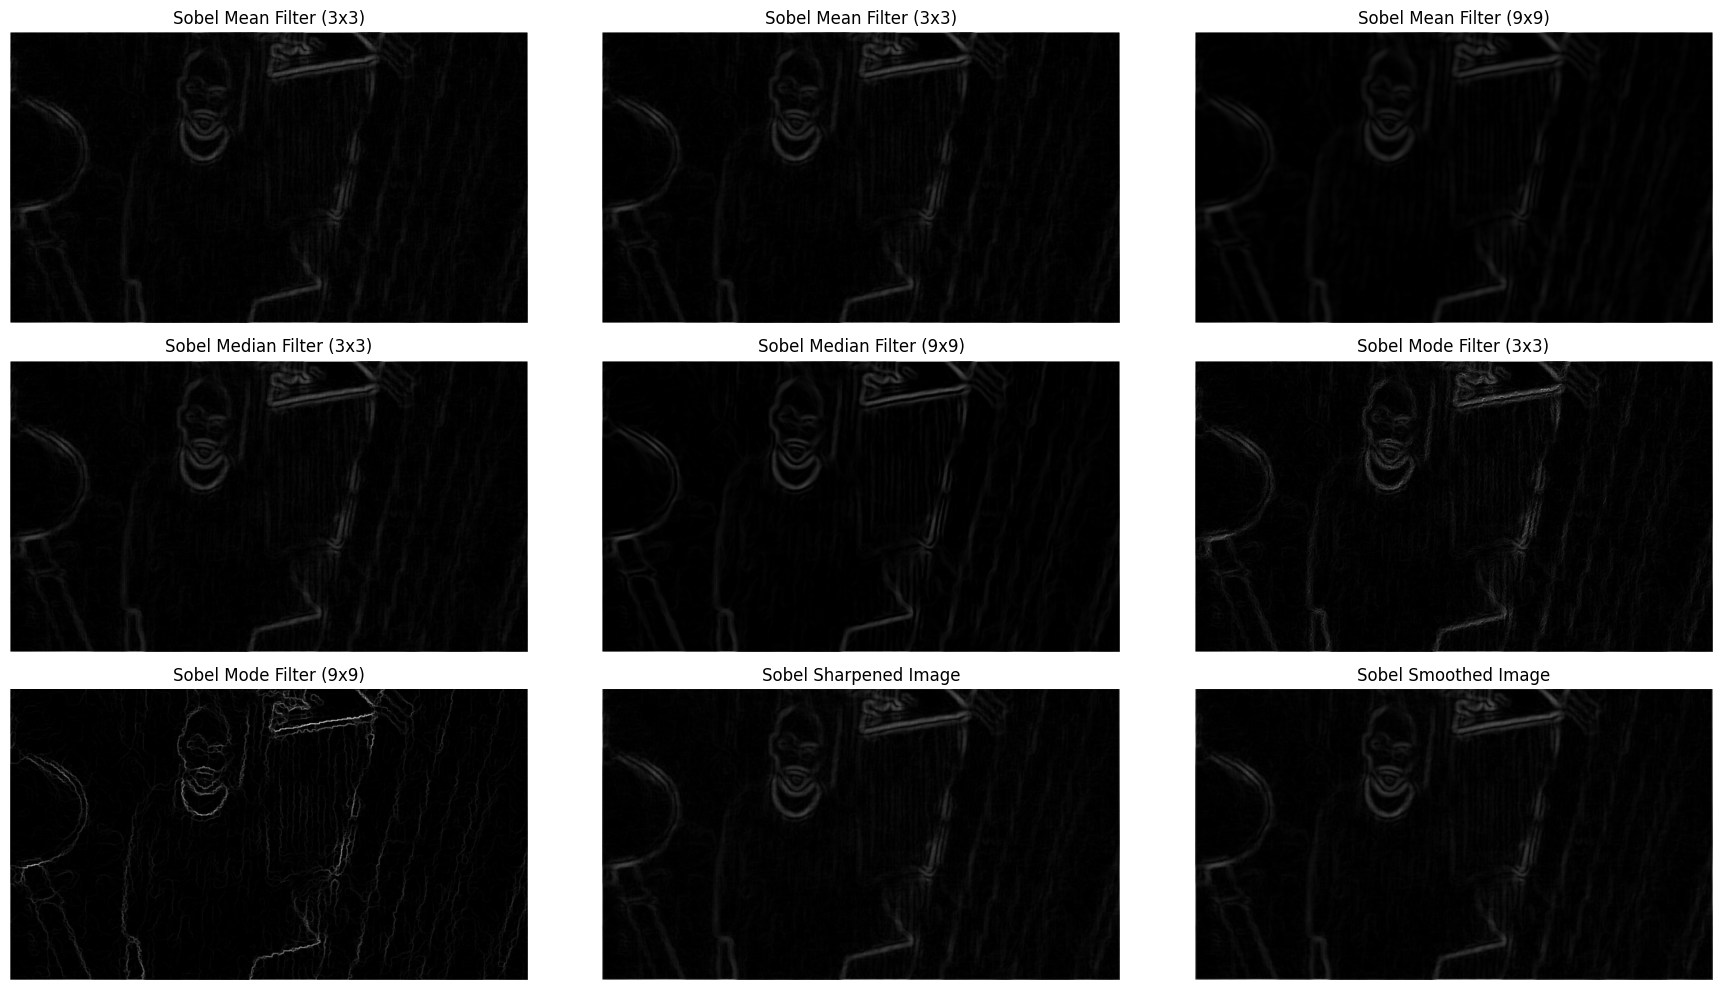

In [ ]:
# SOBEL
sobelOri = edge(sisitv, sobelX, sobelY)

sobelMean3x3   = edge(mean3x3, sobelX, sobelY)
sobelMean9x9   = edge(mean9x9, sobelX, sobelY)

sobelMedian3x3 = edge(median3x3, sobelX, sobelY)
sobelMedian9x9 = edge(median9x9, sobelX, sobelY)

sobelModus3x3  = edge(modus3x3, sobelX, sobelY)
sobelModus9x9  = edge(modus9x9, sobelX, sobelY)

sobelSharp     = edge(sharpening, sobelX, sobelY)
sobelSmooth    = edge(smoothing, sobelX, sobelY)


plt.figure(figsize=(18,10))

plt.subplot(3,3,1)
plt.imshow(sobelOri, cmap='gray')
plt.title('Sobel Ori Filter (3x3)')
plt.axis('off')

plt.subplot(3,3,2)
plt.imshow(sobelMean3x3, cmap='gray')
plt.title('Sobel Mean Filter (3x3)')
plt.axis('off')

plt.subplot(3,3,3)
plt.imshow(sobelMean9x9, cmap='gray')
plt.title('Sobel Mean Filter (9x9)')
plt.axis('off')

plt.subplot(3,3,4)
plt.imshow(sobelMedian3x3, cmap='gray')
plt.title('Sobel Median Filter (3x3)')
plt.axis('off')

plt.subplot(3,3,5)
plt.imshow(sobelMedian9x9, cmap='gray')
plt.title('Sobel Median Filter (9x9)')
plt.axis('off')

plt.subplot(3,3,6)
plt.imshow(sobelModus3x3, cmap='gray')
plt.title('Sobel Mode Filter (3x3)')
plt.axis('off')

plt.subplot(3,3,7)
plt.imshow(sobelModus9x9, cmap='gray')
plt.title('Sobel Mode Filter (9x9)')
plt.axis('off')

plt.subplot(3,3,8)
plt.imshow(sobelSharp, cmap='gray')
plt.title('Sobel Sharpened Image')
plt.axis('off')

plt.subplot(3,3,9)
plt.imshow(sobelSmooth, cmap='gray')
plt.title('Sobel Smoothed Image')
plt.axis('off')

plt.tight_layout()
plt.show()

untuk mendeteksi tepi dipake operator sobel, kalo pakai sobel hasil tepinya masih jelas karena ada pendekatan pada fungsi karnel nya

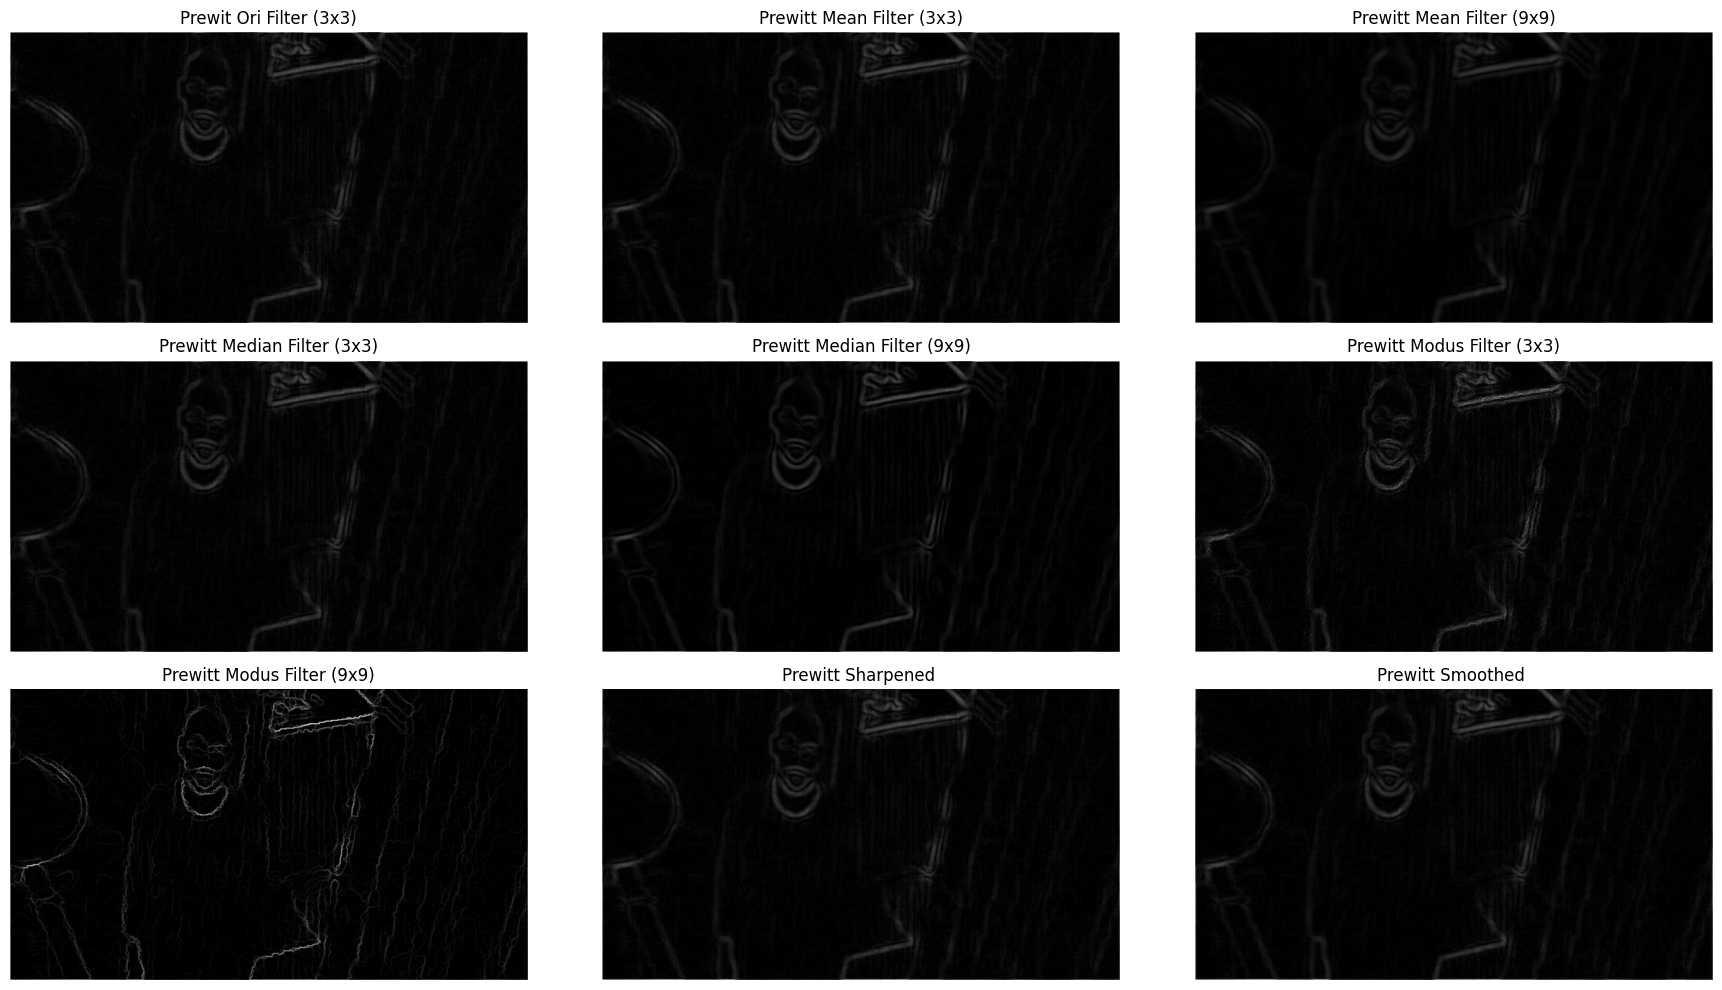

In [53]:
# PREWITT
prewittOri = edge(sisitv, prewittX, prewittY)

prewittMean3x3   = edge(mean3x3, prewittX, prewittY)
prewittMean9x9   = edge(mean9x9, prewittX, prewittY)

prewittMedian3x3 = edge(median3x3, prewittX, prewittY)
prewittMedian9x9 = edge(median9x9, prewittX, prewittY)

prewittModus3x3  = edge(modus3x3, prewittX, prewittY)
prewittModus9x9  = edge(modus9x9, prewittX, prewittY)

prewittSharp     = edge(sharpening, prewittX, prewittY)
prewittSmooth    = edge(smoothing, prewittX, prewittY)


plt.figure(figsize=(18,10))

plt.subplot(3,3,1)
plt.imshow(prewittOri, cmap='gray')
plt.title('Prewit Ori Filter (3x3)')
plt.axis('off')

plt.subplot(3,3,2)
plt.imshow(prewittMean3x3, cmap='gray')
plt.title('Prewitt Mean Filter (3x3)')
plt.axis('off')

plt.subplot(3,3,3)
plt.imshow(prewittMean9x9, cmap='gray')
plt.title('Prewitt Mean Filter (9x9)')
plt.axis('off')

plt.subplot(3,3,4)
plt.imshow(prewittMedian3x3, cmap='gray')
plt.title('Prewitt Median Filter (3x3)')
plt.axis('off')

plt.subplot(3,3,5)
plt.imshow(prewittMedian9x9, cmap='gray')
plt.title('Prewitt Median Filter (9x9)')
plt.axis('off')

plt.subplot(3,3,6)
plt.imshow(prewittModus3x3, cmap='gray')
plt.title('Prewitt Modus Filter (3x3)')
plt.axis('off')

plt.subplot(3,3,7)
plt.imshow(prewittModus9x9, cmap='gray')
plt.title('Prewitt Modus Filter (9x9)')
plt.axis('off')

plt.subplot(3,3,8)
plt.imshow(prewittSharp, cmap='gray')
plt.title('Prewitt Sharpened ')
plt.axis('off')

plt.subplot(3,3,9)
plt.imshow(prewittSmooth, cmap='gray')
plt.title('Prewitt Smoothed ')
plt.axis('off')

plt.tight_layout()
plt.show()

untuk mendeteksi tepi dipake operator prewitt, kalo pakai prewit hasil tepinya masih cukup terlihat karena hampir mirip dengan sobel tapi gada pendekatan pada fungsi karnel nya

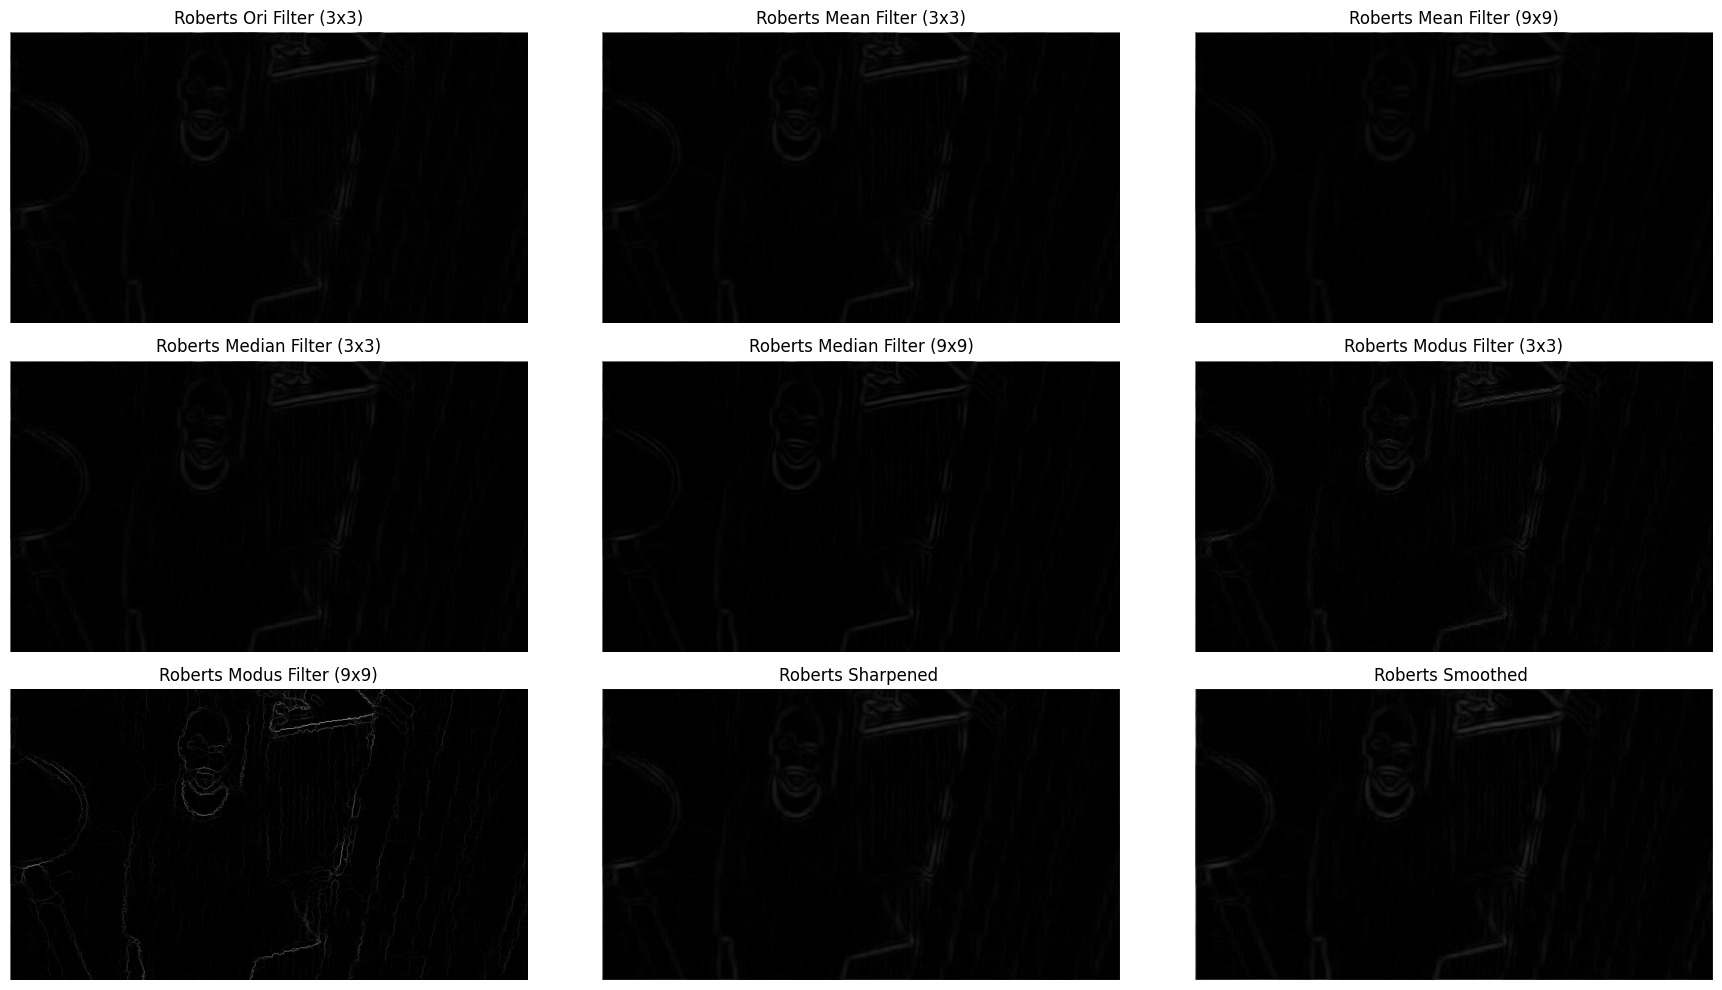

In [56]:
# ROBERTS
robertsOri = edge(sisitv, robertsX, robertsY)

robertsMean3x3   = edge(mean3x3, robertsX, robertsY)
robertsMean9x9   = edge(mean9x9, robertsX, robertsY)

robertsMedian3x3 = edge(median3x3, robertsX, robertsY)
robertsMedian9x9 = edge(median9x9, robertsX, robertsY)

robertsModus3x3  = edge(modus3x3, robertsX, robertsY)
robertsModus9x9  = edge(modus9x9, robertsX, robertsY)

robertsSharp     = edge(sharpening, robertsX, robertsY)
robertsSmooth    = edge(smoothing, robertsX, robertsY)


plt.figure(figsize=(18,10))

plt.subplot(3,3,1)
plt.imshow(robertsOri, cmap='gray')
plt.title('Roberts Ori Filter (3x3)')
plt.axis('off')

plt.subplot(3,3,2)
plt.imshow(robertsMean3x3, cmap='gray')
plt.title('Roberts Mean Filter (3x3)')
plt.axis('off')

plt.subplot(3,3,3)
plt.imshow(robertsMean9x9, cmap='gray')
plt.title('Roberts Mean Filter (9x9)')
plt.axis('off')

plt.subplot(3,3,4)
plt.imshow(robertsMedian3x3, cmap='gray')
plt.title('Roberts Median Filter (3x3)')
plt.axis('off')

plt.subplot(3,3,5)
plt.imshow(robertsMedian9x9, cmap='gray')
plt.title('Roberts Median Filter (9x9)')
plt.axis('off')

plt.subplot(3,3,6)
plt.imshow(robertsModus3x3, cmap='gray')
plt.title('Roberts Modus Filter (3x3)')
plt.axis('off')

plt.subplot(3,3,7)
plt.imshow(robertsModus9x9, cmap='gray')
plt.title('Roberts Modus Filter (9x9)')
plt.axis('off')

plt.subplot(3,3,8)
plt.imshow(robertsSharp, cmap='gray')
plt.title('Roberts Sharpened ')
plt.axis('off')

plt.subplot(3,3,9)
plt.imshow(robertsSmooth, cmap='gray')
plt.title('Roberts Smoothed ')
plt.axis('off')

plt.tight_layout()
plt.show()

untuk mendeteksi tepi dipake operator robert, kalo pakai robert hasil tepinya kurang jelas karena ada pmenggunakan matriks 2x2 pada fungsi karnel nya

(np.float64(-0.5), np.float64(799.5), np.float64(449.5), np.float64(-0.5))

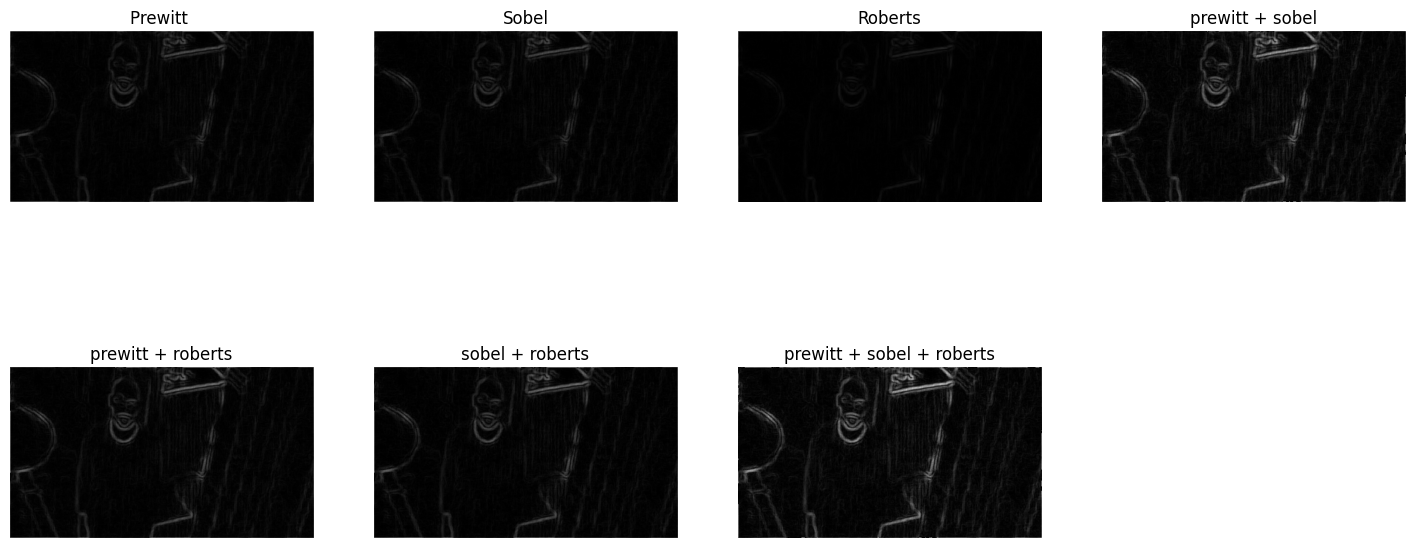

In [59]:
# ukuran 3x3

presol = prewittOri + sobelOri
prerob = prewittOri + robertsOri
sorob = sobelOri + robertsOri
presorob = presol + robertsOri

plt.figure(figsize=(18,8))

plt.subplot(2,4,1)
plt.imshow(prewittOri, cmap = 'gray')
plt.title('Prewitt ')
plt.axis('off')

plt.subplot(2,4,2)
plt.imshow(sobelOri, cmap = 'gray')
plt.title('Sobel')
plt.axis('off')

plt.subplot(2,4,3)
plt.imshow(robertsOri, cmap = 'gray')
plt.title('Roberts')
plt.axis('off')

plt.subplot(2,4,4)
plt.imshow(presol, cmap = 'gray')
plt.title('prewitt + sobel')
plt.axis('off')

plt.subplot(2,4,5)
plt.imshow(prerob, cmap = 'gray')
plt.title('prewitt + roberts')
plt.axis('off')

plt.subplot(2,4,6)
plt.imshow(sorob, cmap = 'gray')
plt.title('sobel + roberts')
plt.axis('off')

plt.subplot(2,4,7)
plt.imshow(presorob, cmap = 'gray')
plt.title('prewitt + sobel + roberts')
plt.axis('off')


hasil dari penggabungannya itu makin jelas kalau ditambah dari kombinasi operator